# Object Detection
Is the two-step process for detecting a specified image/figure and then classify each detected image.
They generate several predictions from a single image.\
The foundational acrchitecture is called *U-NET* which is the facto design approach for image segmentation.
## Image Segmentation
It is a classification problem that classifies *every pixel*. A 200 x 200 image will have 40,000 classifications.
### Nuclei detection: Loading the data
Example using the 2018 Data Science Bowl. 

In [1]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
#from idlmam import *
from sklearn.metrics import accuracy_score

# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = False  # False is better for RNNs with variable input sizes, True for CNNs

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')

 dl_utils loaded
Device available: cuda


/home/efrain/Documents/Bio-AI-foundations/DL_utils_EZA/dl_utils.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


### Representing the image segmentation problem in PyTorch
Use the data to visulize some images

In [2]:
# Visualize the data
from glob import glob

paths = sorted(glob("./data/DSB/stage1_train/*/"))
print(f"✅ Found {len(paths)} samples.") 

✅ Found 670 samples.


In [3]:
dsb_data = DSB2018_EZA(paths)
print(f"Dataset length : {len(dsb_data)}")

img, mask = dsb_data[0]
print(f"Image shape    : {img.shape}")    # → torch.Size([3, 256, 256])
print(f"Mask shape     : {mask.shape}")   # → torch.Size([1, 256, 256])
print(f"Image range    : [{img.min():.3f}, {img.max():.3f}]")    # → [0.0, 1.0]
print(f"Mask unique    : {mask.unique()}")  # → tensor([0., 1.])  ← must be binary!


Dataset length : 670
Image shape    : torch.Size([3, 256, 256])
Mask shape     : torch.Size([1, 256, 256])
Image range    : [0.004, 0.424]
Mask unique    : tensor([0., 1.])


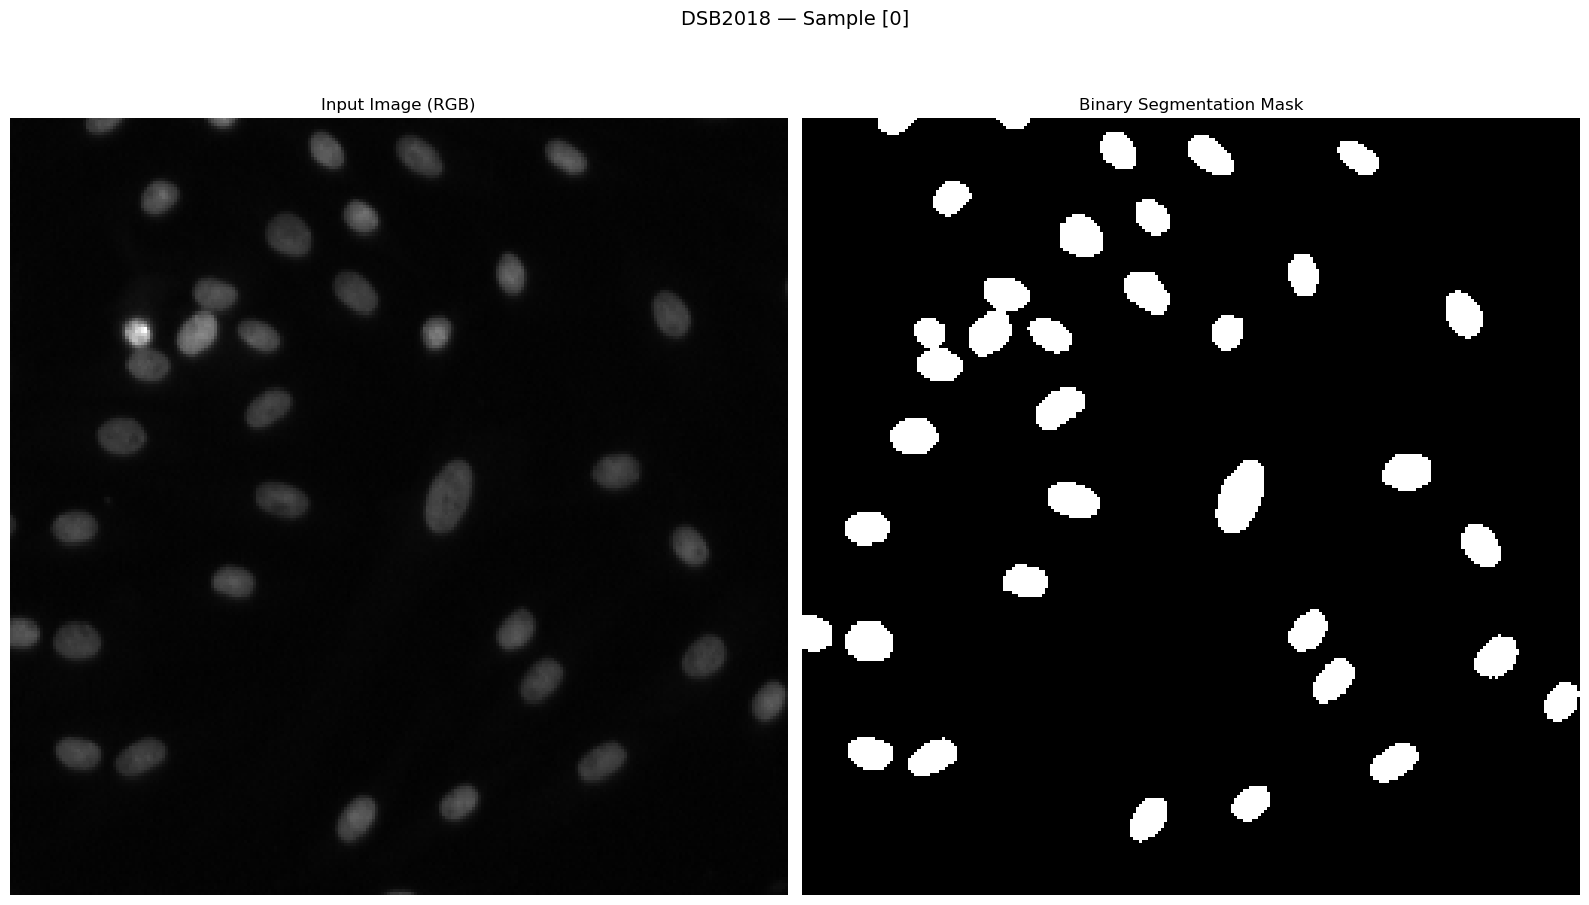

In [4]:
# Better code to visualize the data
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

axes[0].imshow(dsb_data[1][0].permute(1, 2, 0).numpy())  # CHW → HWC for matplotlib
axes[0].set_title("Input Image (RGB)")
axes[0].axis("off")

axes[1].imshow(dsb_data[1][1].numpy()[0, :], cmap="gray")  # (1,H,W) → (H,W)
axes[1].set_title("Binary Segmentation Mask")
axes[1].axis("off")

plt.suptitle("DSB2018 — Sample [0]", fontsize=14)
plt.tight_layout()
plt.show()

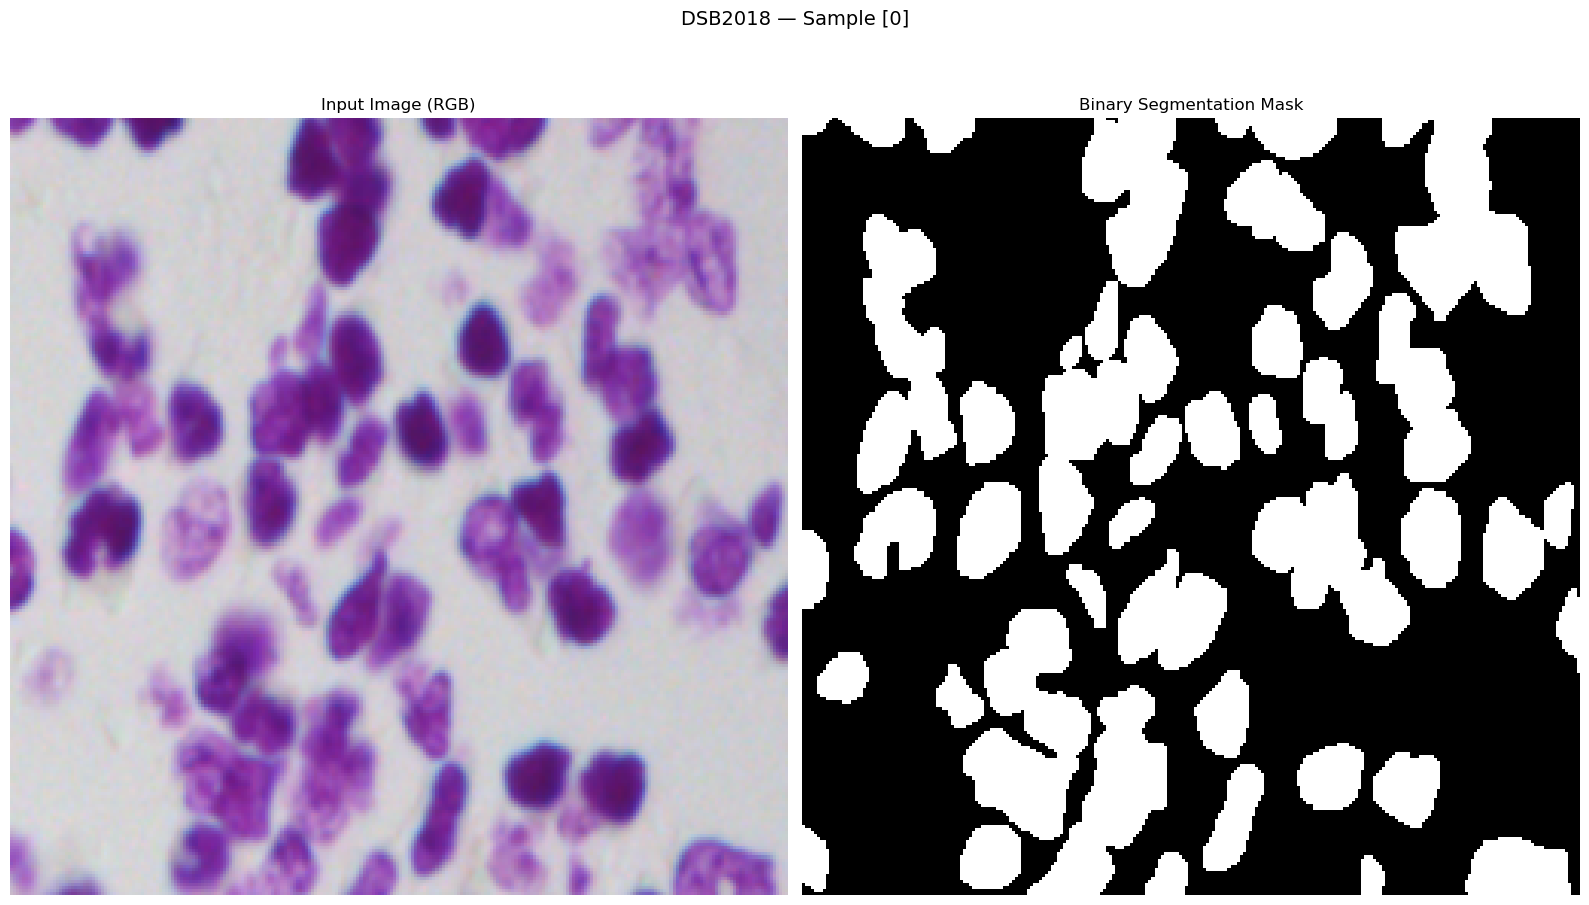

In [5]:
# Better code to visualize the data
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

axes[0].imshow(dsb_data[2][0].permute(1, 2, 0).numpy())  # CHW → HWC for matplotlib
axes[0].set_title("Input Image (RGB)")
axes[0].axis("off")

axes[1].imshow(dsb_data[2][1].numpy()[0, :], cmap="gray")  # (1,H,W) → (H,W)
axes[1].set_title("Binary Segmentation Mask")
axes[1].axis("off")

plt.suptitle("DSB2018 — Sample [0]", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Prepare the data loader for training
train_split, test_split =  torch.utils.data.random_split(dsb_data, [500,len(dsb_data) - 500])

train_seg_loader = DataLoader(
    train_split,
    batch_size=8,       # safe for 10.57 GB VRAM at 256×256
    shuffle=True,
    num_workers=4,      # half your 8 logical cores
    pin_memory=True,    # critical for Thunderbolt 3 eGPU transfers
)

test_seg_loader = DataLoader(
    test_split,
    batch_size=16,
    shuffle=False,      # never shuffle validation
    num_workers=4,
    pin_memory=True,
)

In [5]:
# hyperparameters
C = 3
n_filters = 32
loss_fn = nn.BCEWithLogitsLoss() # Binary Cross Entropy with Logits Loss (combines sigmoid + BCE in one step)

### Building the image segmentation network
We make predictions for every pixel. The imput is $(B, C, W, H)$, the ouptut should be $(B, class, W, H)$.\
Do not use poling to week same W and H values.

In [6]:
# Create a function to make the model code cleaner and more modular
def cnnLayer(in_filters, out_filters, kernel_size=3):
    """ 
    in_filters: number of input channels (e.g. 3 for RGB)
    out_filters: number of output channels
    kernel_size: size of the convolutional kernel
    """
    padding = kernel_size // 2  # to maintain spatial dimensions
    return nn.Sequential(
        nn.Conv2d(in_filters, out_filters, kernel_size=kernel_size, padding=padding),
        nn.BatchNorm2d(out_filters),  # Batch Normalization after convolution
        nn.LeakyReLU(),
    )

In [7]:
# The model architecture
segmentation_model = nn.Sequential(
    cnnLayer(C, n_filters),          # 3 → 32
    *[cnnLayer(n_filters, n_filters) for _ in range(5)],  # 32 → 32
    nn.Conv2d(n_filters, 1, (3,3), padding=1)  # Final layer: 32 → 1, kernel size 3 with padding to maintain dimensions
)

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True is better for CNNs with fixed input sizes

seg_results = train_network_EZA(
    segmentation_model,
    loss_fn,
    train_seg_loader,
    val_loader=test_seg_loader,
    device=device,
    epochs=20,
)

Epoch: 100%|██████████| 20/20 [08:42<00:00, 26.13s/it]


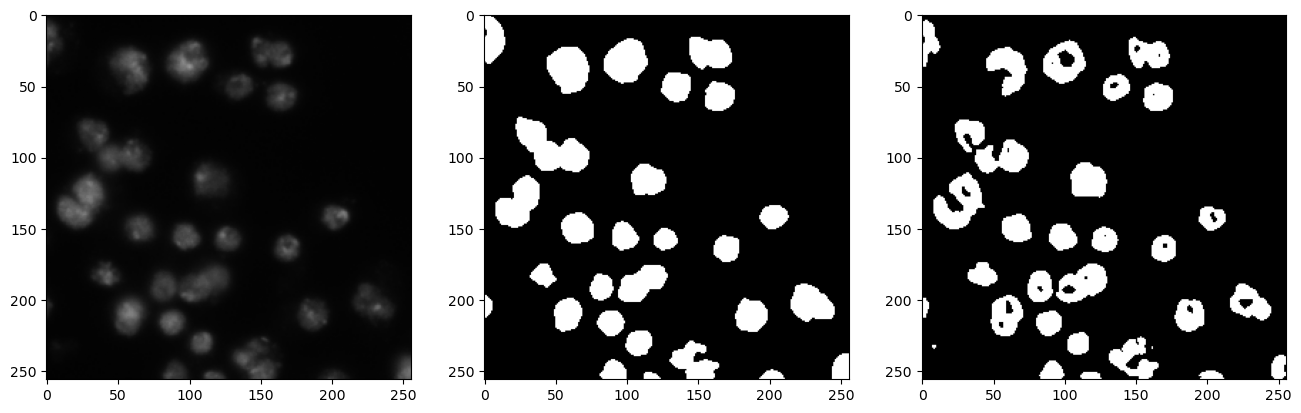

In [8]:
# Test the prediction on the trained model using the test data loader
index = 15
with torch.no_grad():  # No need to track gradients for inference
    logits = segmentation_model(test_split[index][0].unsqueeze(0).to(device))[0].cpu()
    pred = torch.sigmoid(logits) >= 0.5

# Visualize the prediction
plt.figure(figsize=(16, 10))
plt.subplot(1, 3, 1)
plt.imshow(test_split[index][0].permute(1, 2, 0).numpy(), cmap="gray") # Original input image
plt.subplot(1, 3, 2)
plt.imshow(test_split[index][1].numpy()[0, :], cmap="gray") # ground truth mask
plt.subplot(1, 3, 3)
plt.imshow(pred.numpy()[0, :], cmap="gray") # predicted mask

## Transposed convolutions for expanding image size
Is use to use pooling to get a smaller output and then expand back up to a larger form.
### Implementing a network with transposed convolutions
It will work similarly to a autoencoder. We uadd a round of max pooling (reduction) and later one round of transposed convolution (augmentation)

In [9]:
# Network with transpose convolutions
segmentation_model_transpose = nn.Sequential(
    cnnLayer(C, n_filters),          # 3 → 32
    cnnLayer(n_filters, n_filters),  # 32 → 32
    nn.MaxPool2d(2),                 # 32 → 32, spatial downsample by 2
    cnnLayer(n_filters, 2*n_filters),  # 32 → 64
    *[cnnLayer(2*n_filters, 2*n_filters) for _ in range(2)],  # 64 → 64
    nn.ConvTranspose2d(2*n_filters, n_filters, (3,3), padding=1, output_padding=1, stride=2),  # 64 → 32, spatial upsample by 2
    nn.BatchNorm2d(n_filters),
    nn.LeakyReLU(),
    cnnLayer(n_filters, n_filters),  # 32 → 32
    nn.Conv2d(n_filters, 1, (3,3), padding=1)  # Final layer: 32 → 1, kernel size 3 with padding to maintain
)


In [10]:
# Train the model with transpose convolutions

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True is better for CNNs with fixed input sizes

seg_results_transpose = train_network_EZA(
    segmentation_model_transpose,
    loss_fn,
    train_seg_loader,
    val_loader=test_seg_loader,
    device=device,
    epochs=20,
)

Epoch: 100%|██████████| 20/20 [08:29<00:00, 25.46s/it]


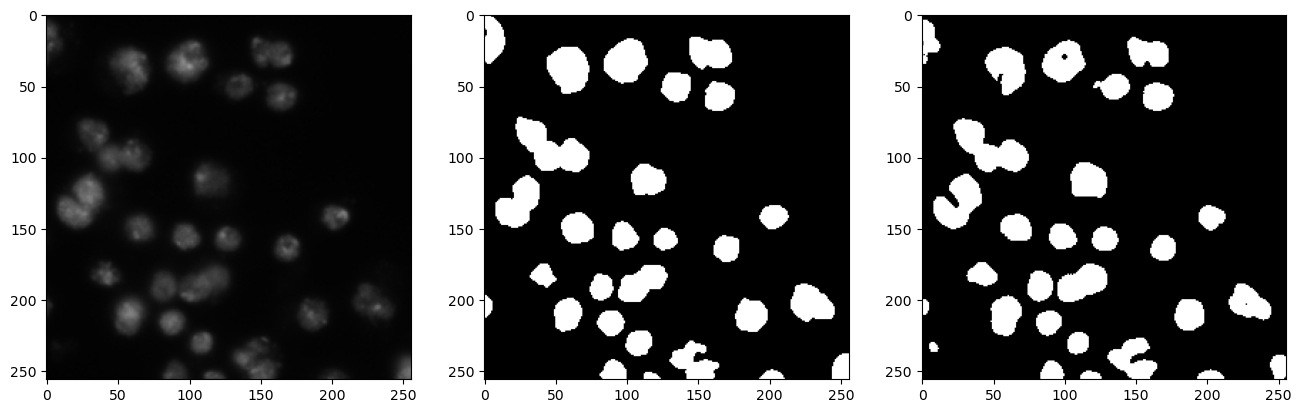

In [11]:
# See results

# Use the previous value for index to test the same sample as before

with torch.no_grad():  # No need to track gradients for inference
    pred_transpose = segmentation_model_transpose(
        test_split[index][0].unsqueeze(0).to(device))[0].cpu()
    pred_transpose = torch.sigmoid(pred_transpose) >= 0.5

# Visualize the prediction
plt.figure(figsize=(16, 10))
plt.subplot(1, 3, 1)
plt.imshow(test_split[index][0].permute(1, 2, 0).numpy(), cmap="gray") # Original input image
plt.subplot(1, 3, 2)
plt.imshow(test_split[index][1].numpy()[0, :], cmap="gray") # ground truth mask
plt.subplot(1, 3, 3)
plt.imshow(pred_transpose.numpy()[0, :], cmap="gray") # predicted mask

Text(0.5, 1.0, 'Validation Loss Over Time')

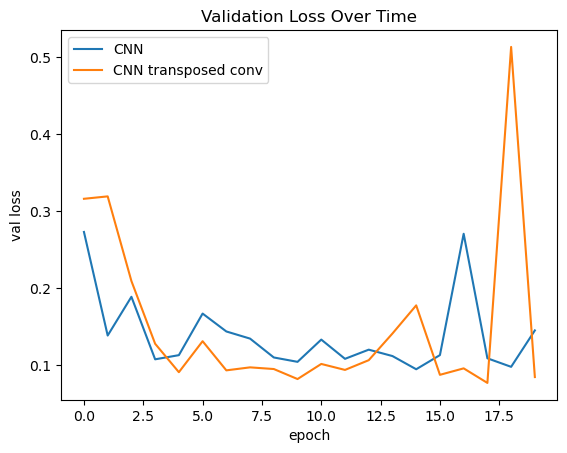

In [12]:
# Verify that the validation loss is decreasing over time
sns.lineplot(x="epoch", y="val loss", data=seg_results, label="CNN")
sns.lineplot(x="epoch", y="val loss", data=seg_results_transpose, label="CNN transposed conv")
plt.title("Validation Loss Over Time")